# 01 — EDA: Quantitative Distribution Audit

Each section is a **checkpoint**: run the cell, evaluate the output, then proceed.
All logic lives in `src/` — this notebook only calls it and displays results.

```
STEP 1  Load raw CSVs
STEP 2  Join by study (uid)
STEP 3  Integrity check + sample findings text
STEP 4  CheXbert labels  ← slow on CPU (~10–20 min); cached after first run
STEP 5  Label prevalences
STEP 6  K_eff and entropy
STEP 7  Class ESS
STEP 8  Tail mass
STEP 9  Co-occurrence matrix
STEP 10 Association rules mining
STEP 11 Label cluster dendrogram
STEP 12 Save figures
```

In [ ]:
import logging
import yaml
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
logging.basicConfig(level=logging.INFO, format='%(levelname)s  %(message)s')

with open('../params.yaml') as f:
    params = yaml.safe_load(f)

RAW_DIR       = Path('../') / params['data']['raw_dir']
PROCESSED_DIR = Path('../') / params['data']['processed_dir']
FIGURES_DIR   = Path('../reports/figures')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('RAW_DIR      :', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)
print('Files in raw :', list(RAW_DIR.glob('*')) if RAW_DIR.exists() else 'MISSING')

RAW_DIR      : ../data/raw
PROCESSED_DIR: ../data/processed
Files in raw : [PosixPath('../data/raw/indiana_reports.csv'), PosixPath('../data/raw/images'), PosixPath('../data/raw/indiana_projections.csv')]


## STEP 1 — Load raw CSVs
Evaluate: correct column names? expected row counts?

In [2]:
from src.data.load import load_reports, load_projections

reports     = load_reports(RAW_DIR)
projections = load_projections(RAW_DIR)

print(f'reports:     {reports.shape}     columns: {reports.columns.tolist()}')
print(f'projections: {projections.shape}  columns: {projections.columns.tolist()}')

INFO  Loaded 3851 report rows from ../data/raw/indiana_reports.csv
INFO  Loaded 7466 projection rows from ../data/raw/indiana_projections.csv


reports:     (3851, 8)     columns: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']
projections: (7466, 3)  columns: ['uid', 'filename', 'projection']


In [3]:
# Peek at both tables
print('=== reports (first 3 rows) ===')
display(reports.head(3))
print('\n=== projections (first 6 rows) ===')
display(projections.head(6))

=== reports (first 3 rows) ===


,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."



=== projections (first 6 rows) ===


,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal
5,3,3_IM-1384-2001.dcm.png,Lateral


In [ ]:
# Null counts per column — know what's missing before joining
print('=== reports null counts ===')
print(reports.isnull().sum().to_string())
print('\n=== projections null counts ===')
print(projections.isnull().sum().to_string())

=== reports null counts ===
uid              0
MeSH             0
Problems         0
image            0
indication      86
comparison    1166
findings       514
impression      31

=== projections null counts ===
uid           0
filename      0
projection    0


## STEP 2 — Join by study (uid)
Evaluate: one row per study? frontal + lateral images collapsed to lists?

In [5]:
from src.data.load import build_study_df

df = build_study_df(reports, projections)

print(f'Shape after join: {df.shape}  (should be ≈ n_unique_uids x n_cols)')
print(f'Unique UIDs in reports:     {reports["uid"].nunique()}')
print(f'Unique UIDs after join:     {df["uid"].nunique()}')
print(f'Columns: {df.columns.tolist()}')
display(df.head(3))

Shape after join: (3851, 10)  (should be ≈ n_unique_uids x n_cols)
Unique UIDs in reports:     3851
Unique UIDs after join:     3851
Columns: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'frontal', 'lateral']


,uid,MeSH,Problems,image,indication,comparison,findings,impression,frontal,lateral
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,[1_IM-0001-4001.dcm.png],[1_IM-0001-3001.dcm.png]
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,[2_IM-0652-1001.dcm.png],[2_IM-0652-2001.dcm.png]
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p...",[3_IM-1384-1001.dcm.png],[3_IM-1384-2001.dcm.png]


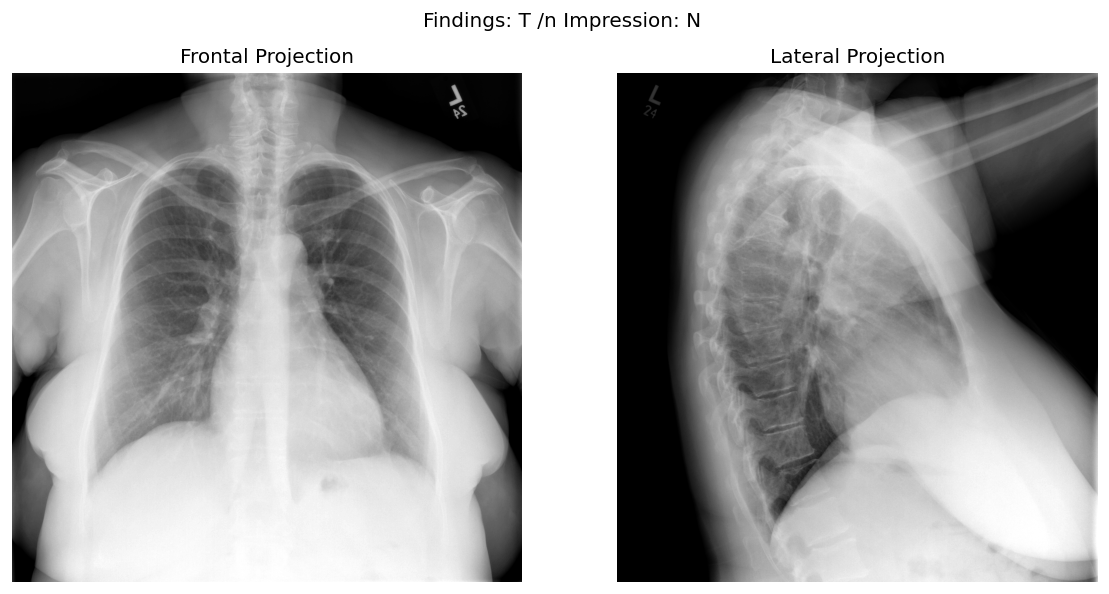

In [7]:
# Example of image tailored with its disgnosis 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_data = df.sample(n=1)


frontal_path = "../data/raw/images/images_normalized/"+ sample_data['frontal'].iloc[0][0]
lateral_path = "../data/raw/images/images_normalized/"+ sample_data['lateral'].iloc[0][0]

findings = sample_data['findings'].iloc[0]
impression = sample_data['impression'].iloc[0]


# 2. Create a side-by-side layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(f"Findings: {findings} /n Impression: {impression}")


axes[0].imshow(mpimg.imread(frontal_path), cmap='gray')
axes[0].set_title("Frontal Projection")
axes[0].axis('off')


axes[1].imshow(mpimg.imread(lateral_path), cmap='gray')
axes[1].set_title("Lateral Projection")
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [6]:
# Check how many studies have frontal and/or lateral images
if 'frontal' in df.columns:
    n_frontal  = df['frontal'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False).sum()
    print(f'Studies with frontal image:  {n_frontal} / {len(df)}')
if 'lateral' in df.columns:
    n_lateral  = df['lateral'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False).sum()
    print(f'Studies with lateral image:  {n_lateral} / {len(df)}')

# Distribution of projection counts per study
proj_counts = projections.groupby('uid')['filename'].count()
proj_counts.value_counts().sort_index().rename('n_studies').to_frame()

Studies with frontal image:  3689 / 3851
Studies with lateral image:  3550 / 3851


,n_studies
filename,
1,446
2,3210
3,181
4,13
5,1


## STEP 3 — Integrity check + sample findings text
Evaluate: how many studies are unusable (no findings)? Does the text look clinical?

In [7]:
from src.data.load import validate_integrity

stats = validate_integrity(df)
pd.Series(stats).rename('count').to_frame()

INFO  total_studies: 3851
WARNING  studies_without_frontal_image: 162
WARNING  studies_with_empty_findings: 514


,count
total_studies,3851
studies_without_frontal_image,162
studies_with_empty_findings,514


In [8]:
# Drop studies with no findings text (can't be used as generation targets)
mask = df['findings'].notna() & (df['findings'].astype(str).str.strip() != '')
df_clean = df[mask].reset_index(drop=True)

print(f'Before: {len(df)} studies')
print(f'After dropping empty findings: {len(df_clean)} studies')
print(f'Dropped: {len(df) - len(df_clean)}')

Before: 3851 studies
After dropping empty findings: 3337 studies
Dropped: 514


In [9]:
# Read 3 example studies — check text quality and clinical relevance
for i in [0, 1, 2]:
    row = df_clean.iloc[i]
    print(f"\n{'='*60}")
    print(f"UID: {row['uid']}")
    print(f"Indication : {str(row.get('indication', 'N/A'))[:150]}")
    print(f"Findings   : {str(row['findings'])[:300]}")
    print(f"Impression : {str(row.get('impression', 'N/A'))[:150]}")


UID: 1
Indication : Positive TB test
Findings   : The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.
Impression : Normal chest x-XXXX.

UID: 2
Indication : Preop bariatric surgery.
Findings   : Borderline cardiomegaly. Midline sternotomy XXXX. Enlarged pulmonary arteries. Clear lungs. Inferior XXXX XXXX XXXX.
Impression : No acute pulmonary findings.

UID: 4
Indication : XXXX-year-old XXXX with XXXX.
Findings   : There are diffuse bilateral interstitial and alveolar opacities consistent with chronic obstructive lung disease and bullous emphysema. There are irregular opacities in the left lung apex, that could represent a cavitary lesion in the left lung apex.There are streaky opacities in the right upper lob
Impression : 1. Bullous emphysema and interstitial fibrosis. 2. Probably scarring in the left apex, although difficult to

## STEP 4 — CheXbert labels

**First run:** downloads ~400 MB CheXbert model from HuggingFace, then runs BERT
over all ~3 k reports. Takes **~10–20 min on CPU**. Results are cached to disk.

**Subsequent runs:** loads instantly from the cache parquet.

Evaluate: does the label matrix look sensible? Are the all-zero rows (no finding) dominant?

In [10]:
from src.data.labels import label_dataframe, CHEXBERT_LABELS

LABEL_CACHE = PROCESSED_DIR / 'chexbert_labels.parquet'

print(f'Cache exists: {LABEL_CACHE.exists()}')
print('Running label_dataframe (loading from cache if available)...')

df_labeled = label_dataframe(
    df_clean,
    uncertain_policy=params['labels']['uncertain_policy'],
    device=params['labels']['device'],
    cache_path=LABEL_CACHE,
)

print(f'\nShape: {df_labeled.shape}')
print(f'Label columns added: {CHEXBERT_LABELS}')

Cache exists: False
Running label_dataframe (loading from cache if available)...


INFO  Running CheXbert on 3337 texts (policy=present, device=cpu, batch=32)
INFO  HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO  HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO  HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO  HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO  HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO  HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
WARNING  Warning: You are sending unauthenticated r


Shape: (3337, 24)
Label columns added: ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'No Finding']


In [11]:
# Inspect label matrix — first 10 rows
display(df_labeled[['uid', 'findings'] + CHEXBERT_LABELS].head(10))

,uid,findings,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,1,The cardiac silhouette and mediastinum size ar...,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,2,Borderline cardiomegaly. Midline sternotomy XX...,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,4,There are diffuse bilateral interstitial and a...,0,0,1,1,0,0,0,0,0,0,0,0,0,0
3,5,The cardiomediastinal silhouette and pulmonary...,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,6,Heart size and mediastinal contour are within ...,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,7,The cardiac contours are normal. XXXX basilar ...,0,0,0,0,0,0,0,1,0,0,0,0,0,0
6,8,"The heart, pulmonary XXXX and mediastinum are ...",0,0,0,0,0,0,0,0,0,0,0,0,0,1
7,9,The XXXX examination consists of frontal and l...,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,10,The cardiomediastinal silhouette is within nor...,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,11,Cardiomediastinal silhouette and pulmonary vas...,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [12]:
# Per-label positive count
label_counts = df_labeled[CHEXBERT_LABELS].sum().sort_values(ascending=False)
print('Positive studies per label:')
print(label_counts.to_string())

Positive studies per label:
No Finding                    1293
Lung Opacity                   450
Cardiomegaly                   414
Enlarged Cardiomediastinum     249
Atelectasis                    224
Support Devices                153
Lung Lesion                    134
Fracture                       121
Pleural Effusion               105
Pleural Other                   49
Edema                           44
Pneumonia                       30
Consolidation                   25
Pneumothorax                    17


In [13]:
# Save the labeled dataset so terminal scripts can also use it
out = PROCESSED_DIR / 'dataset_labeled.parquet'
df_labeled.to_parquet(out, index=False)
print(f'Saved to {out}')

Saved to ../data/processed/dataset_labeled.parquet


## STEP 5 — Label prevalences
Evaluate: how dominated is this dataset by "No Finding"? Which labels are rare?

In [14]:
from src.eda.distribution_audit import compute_prevalences

label_matrix = df_labeled[CHEXBERT_LABELS].to_numpy(dtype=np.float32)
prevalences  = compute_prevalences(label_matrix)

print('Label prevalences (fraction of studies):')
print(prevalences.sort_values(ascending=False).to_string())

Label prevalences (fraction of studies):
No Finding                    0.387474
Lung Opacity                  0.134852
Cardiomegaly                  0.124064
Enlarged Cardiomediastinum    0.074618
Atelectasis                   0.067126
Support Devices               0.045850
Lung Lesion                   0.040156
Fracture                      0.036260
Pleural Effusion              0.031465
Pleural Other                 0.014684
Edema                         0.013185
Pneumonia                     0.008990
Consolidation                 0.007492
Pneumothorax                  0.005094


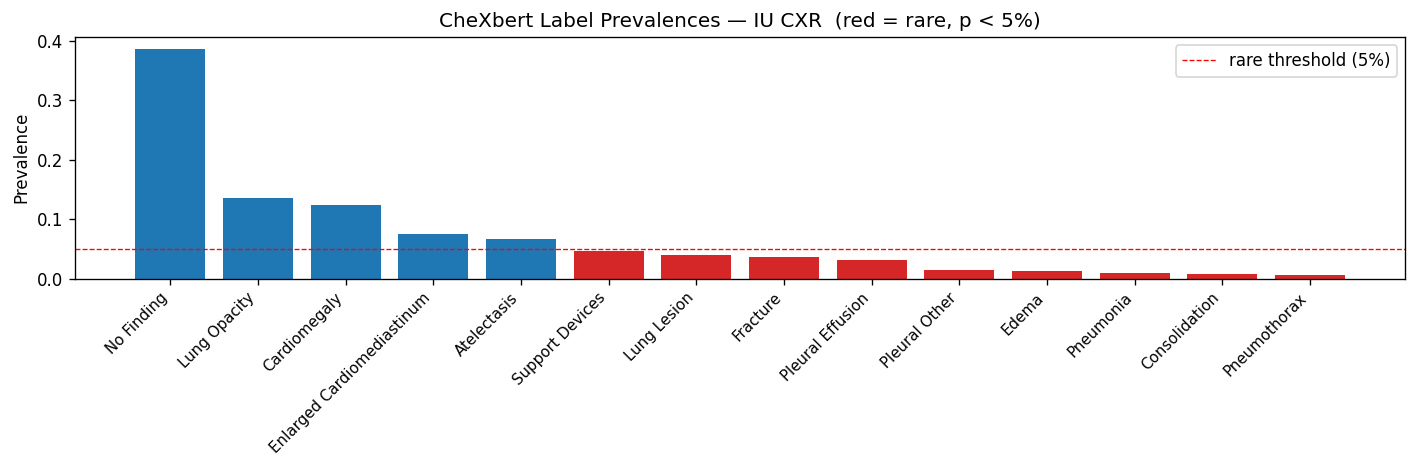

In [15]:
sorted_prev = prevalences.sort_values(ascending=False)
colors = ['#d62728' if v < 0.05 else '#1f77b4' for v in sorted_prev.values]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(sorted_prev)), sorted_prev.values, color=colors)
ax.set_xticks(range(len(sorted_prev)))
ax.set_xticklabels(sorted_prev.index, rotation=45, ha='right', fontsize=9)
ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='rare threshold (5%)')
ax.set_ylabel('Prevalence')
ax.set_title('CheXbert Label Prevalences — IU CXR  (red = rare, p < 5%)')
ax.legend()
plt.tight_layout()
plt.show()

## STEP 6 — K_eff and Shannon entropy
Evaluate: how concentrated is the dataset?
K_eff = 1 → one label dominates entirely. K_eff = 14 → all equal.

In [16]:
from src.eda.distribution_audit import compute_keff

keff = compute_keff(prevalences)
p = prevalences.values.clip(1e-9)
p_norm = p / p.sum()
entropy = float(-np.sum(p_norm * np.log(p_norm)))

print(f'Shannon entropy H  = {entropy:.3f} nats')
print(f'K_eff = exp(H)      = {keff:.2f}  (out of 14 possible)')
print()
print('Interpretation: the dataset behaves as if there are only')
print(f'{keff:.1f} equally-common labels — heavily skewed toward "No Finding".')

Shannon entropy H  = 2.005 nats
K_eff = exp(H)      = 7.42  (out of 14 possible)

Interpretation: the dataset behaves as if there are only
7.4 equally-common labels — heavily skewed toward "No Finding".


## STEP 7 — Per-class ESS
Evaluate: if we up-weight to uniform prevalence, how many *effective* samples does each rare class have?
Low ESS = we don't have much real signal for that class even with reweighting.

In [17]:
from src.eda.distribution_audit import compute_class_ess

class_ess = compute_class_ess(label_matrix, prevalences)
sorted_ess = class_ess.sort_values(ascending=True)

print('Per-class ESS (effective sample size ≈ n_positive):')
print(sorted_ess.to_string())

Per-class ESS (effective sample size ≈ n_positive):
Pneumothorax                    17.0
Consolidation                   25.0
Pneumonia                       30.0
Edema                           44.0
Pleural Other                   49.0
Pleural Effusion               105.0
Fracture                       121.0
Lung Lesion                    134.0
Support Devices                153.0
Atelectasis                    224.0
Enlarged Cardiomediastinum     249.0
Cardiomegaly                   414.0
Lung Opacity                   450.0
No Finding                    1293.0


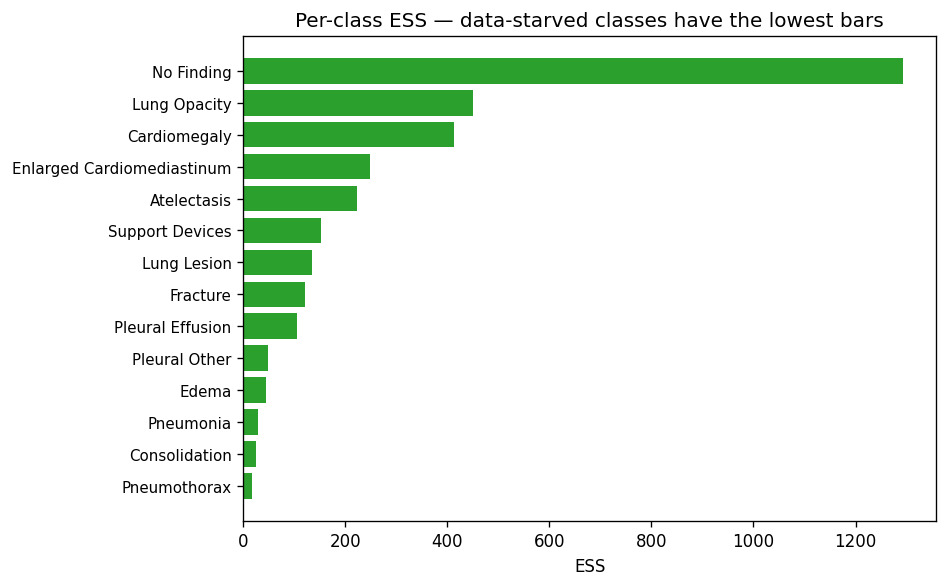

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(sorted_ess)), sorted_ess.values, color='#2ca02c')
ax.set_yticks(range(len(sorted_ess)))
ax.set_yticklabels(sorted_ess.index, fontsize=9)
ax.set_xlabel('ESS')
ax.set_title('Per-class ESS — data-starved classes have the lowest bars')
plt.tight_layout()
plt.show()

## STEP 8 — Tail mass
Evaluate: what fraction of studies only have rare labels (p < 5%)?
These studies get almost no gradient signal under standard training.

In [19]:
from src.eda.distribution_audit import compute_tail_mass

tail_mass = compute_tail_mass(label_matrix)
print(f'Tail mass: {tail_mass:.3f}  ({tail_mass*100:.1f}% of studies)')
print()
print('These are the studies the importance-weighted sampler is most')
print('important for — they\'re the first to be lost under uniform sampling.')

Tail mass: 0.082  (8.2% of studies)

These are the studies the importance-weighted sampler is most
important for — they're the first to be lost under uniform sampling.


## STEP 9 — Label co-occurrence
Evaluate: which labels tend to appear together? Are there clinically expected patterns
(e.g. Edema + Pleural Effusion, Consolidation + Pneumonia)?

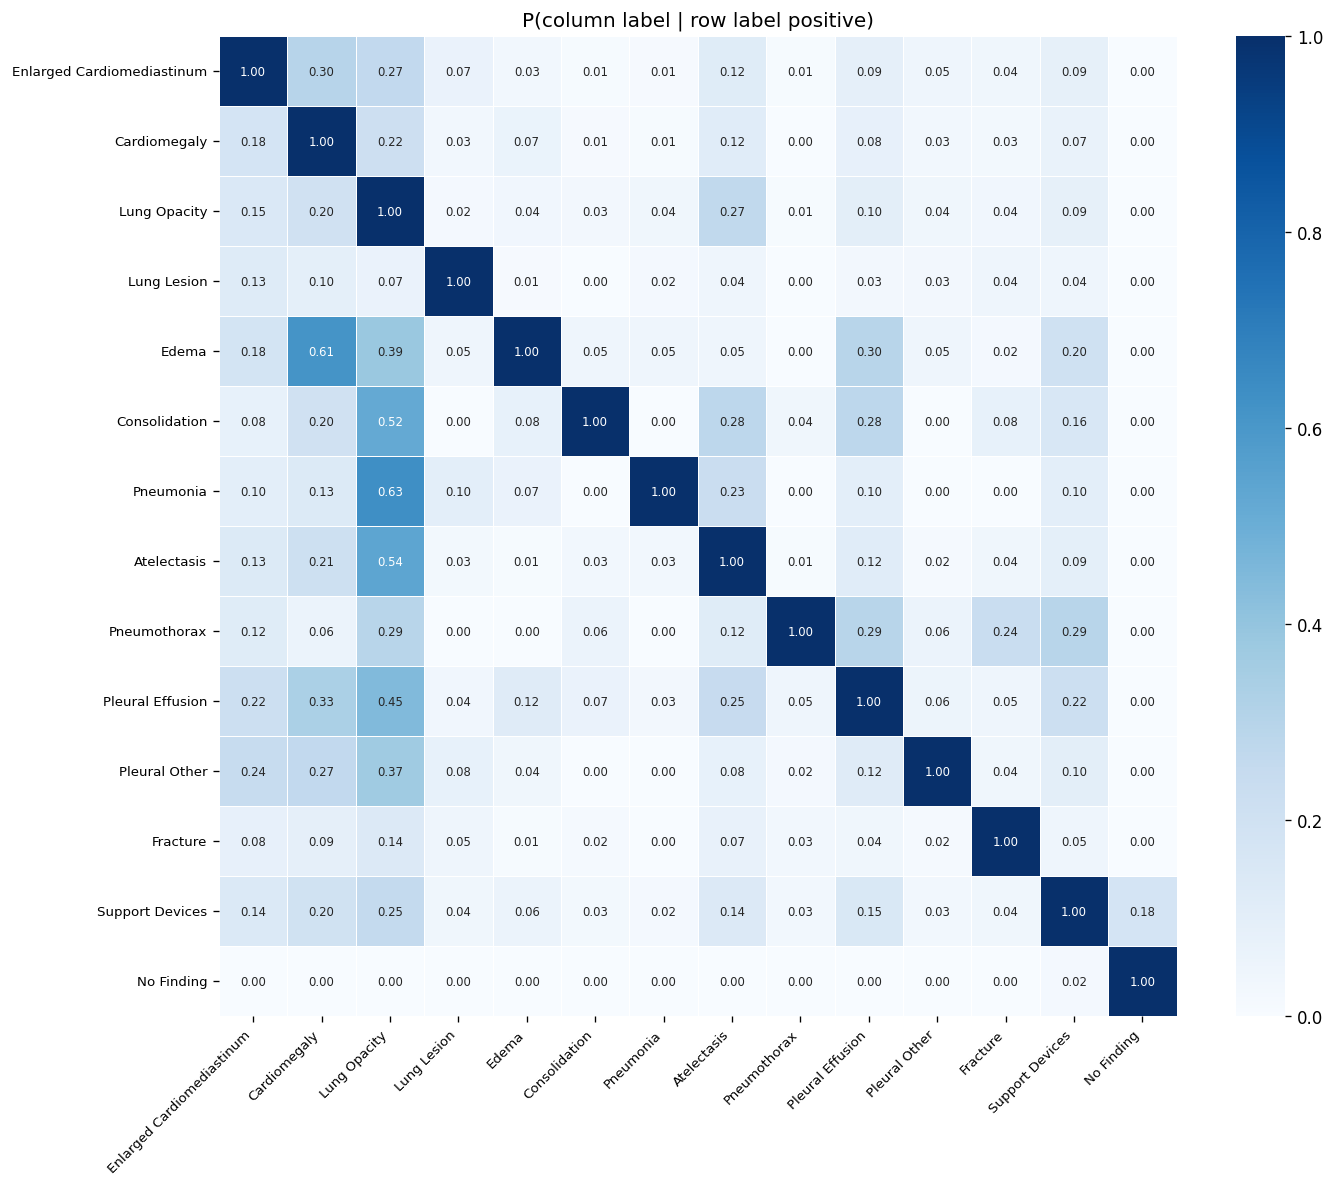

In [20]:
from src.eda.distribution_audit import compute_cooccurrence
import seaborn as sns

cooccurrence = compute_cooccurrence(label_matrix)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cooccurrence, annot=True, fmt='.2f', cmap='Blues',
    vmin=0, vmax=1, ax=ax, linewidths=0.4, annot_kws={'size': 7},
)
ax.set_title('P(column label | row label positive)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
# Top 5 co-occurring pairs (excluding diagonal)
cooc_flat = cooccurrence.copy()
np.fill_diagonal(cooc_flat.values, 0)
top = cooc_flat.unstack().sort_values(ascending=False).head(10)
print('Top 10 label pairs by conditional co-occurrence P(col | row):')
print(top.rename('P(col|row)').to_string())

Top 10 label pairs by conditional co-occurrence P(col | row):
Lung Opacity      Pneumonia                     0.633333
Cardiomegaly      Edema                         0.613636
Lung Opacity      Atelectasis                   0.540179
                  Consolidation                 0.520000
                  Pleural Effusion              0.447619
                  Edema                         0.386364
                  Pleural Other                 0.367347
Cardiomegaly      Pleural Effusion              0.333333
                  Enlarged Cardiomediastinum    0.297189
Pleural Effusion  Edema                         0.295455


## STEP 10 — Association Rules Mining

Computes pairwise directional rules **A → B** from the label co-occurrence matrix.

- **Support**: P(A ∧ B) — how often both appear together
- **Confidence**: P(B | A) — how likely B is given A
- **Lift**: confidence / P(B) — how much more likely B is *given* A vs at random (lift > 1 = positive association)

Rules with lift ≫ 1 are the most interesting: they reveal non-trivial clinical co-occurrences
beyond what base prevalence would predict. `No Finding` is excluded (it's a special label,
not a pathology).

These rules form the statistical foundation for the soft diagnostic prior injected in notebook 06.

In [ ]:
from itertools import combinations

# Exclude 'No Finding' — it's a logical complement, not a pathology
LABELS_PATH = [l for l in CHEXBERT_LABELS if l != 'No Finding']
lm_path = df_labeled[LABELS_PATH].to_numpy(dtype=np.float32)
n_studies = len(lm_path)

prev_path = lm_path.mean(axis=0)
co_path   = (lm_path.T @ lm_path) / n_studies

rules_list = []
for i, la in enumerate(LABELS_PATH):
    if prev_path[i] < 0.01:
        continue
    for j, lb in enumerate(LABELS_PATH):
        if i == j or prev_path[j] < 0.01:
            continue
        p_ab = float(co_path[i, j])
        p_a  = float(prev_path[i])
        p_b  = float(prev_path[j])
        conf = p_ab / p_a
        lift = conf / p_b if p_b > 0 else 0.0
        rules_list.append({
            'antecedent':  la,
            'consequent':  lb,
            'support':     round(p_ab,  4),
            'confidence':  round(conf,  4),
            'lift':        round(lift,  4),
        })

rules_eda = pd.DataFrame(rules_list).sort_values('lift', ascending=False)

# Strong rules only
strong_rules = rules_eda[
    (rules_eda['confidence'] >= 0.25) &
    (rules_eda['lift']       >= 1.50)
].reset_index(drop=True)

print(f'Total rules       : {len(rules_eda)}')
print(f'Strong rules      : {len(strong_rules)}  (conf ≥ 0.25, lift ≥ 1.5)')
print()
display(strong_rules.head(20))

# ── Visualization: confidence and lift for the top 15 rules ───────────────────
top15 = strong_rules.head(15).copy()
top15['rule'] = top15['antecedent'] + '  →  ' + top15['consequent']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top15['rule'][::-1], top15['confidence'][::-1], color='#1f77b4', alpha=0.85)
axes[0].axvline(0.25, color='red', linestyle='--', linewidth=0.8, label='min confidence')
axes[0].set_xlabel('Confidence  P(B | A)')
axes[0].set_title('Top association rules — Confidence')
axes[0].legend(fontsize=8)

axes[1].barh(top15['rule'][::-1], top15['lift'][::-1], color='#ff7f0e', alpha=0.85)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=0.8, label='lift = 1 (random)')
axes[1].axvline(1.5, color='red',   linestyle='--', linewidth=0.8, label='min lift')
axes[1].set_xlabel('Lift')
axes[1].set_title('Top association rules — Lift')
axes[1].legend(fontsize=8)

plt.suptitle('Association Rules: A → B  (No Finding excluded)', fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'assoc_rules_eda.png', dpi=150, bbox_inches='tight')
print('Saved assoc_rules_eda.png')
plt.show()

## STEP 11 — Label Cluster Dendrogram

Groups labels by how similarly they co-occur across studies.
Distance metric: **Jaccard** on binary label vectors (symmetric — does not assume direction).
Clustering method: **average linkage**.

Clusters that emerge here correspond to clinical syndromes:
a cardiac cluster (Cardiomegaly, Edema, Enlarged Cardiomediastinum),
an infection cluster (Pneumonia, Consolidation), etc.
This structure motivates using multi-label antecedents in the prompt conditioner (notebook 06).

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Jaccard distance between label occurrence vectors (columns of the binary matrix)
# Each label is a binary vector over studies; Jaccard = 1 - |A∩B|/|A∪B|
lm_T = lm_path.T.astype(bool)   # shape (n_labels, n_studies)

def jaccard_dist(a, b):
    inter = (a & b).sum()
    union = (a | b).sum()
    return 1.0 - inter / union if union > 0 else 1.0

dist_condensed = pdist(lm_T, metric=jaccard_dist)
Z = linkage(dist_condensed, method='average')

fig, ax = plt.subplots(figsize=(11, 5))
dg = dendrogram(
    Z,
    labels=LABELS_PATH,
    ax=ax,
    leaf_rotation=40,
    leaf_font_size=9,
    color_threshold=0.70 * max(Z[:, 2]),
)
ax.set_title('Hierarchical Clustering of CheXbert Labels (Jaccard distance, average linkage)', fontsize=12)
ax.set_ylabel('Distance')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'label_dendrogram.png', dpi=150, bbox_inches='tight')
print('Saved label_dendrogram.png')
plt.show()

# Print cluster summary at the chosen cut
from scipy.cluster.hierarchy import fcluster
n_clusters = 5
cluster_ids = fcluster(Z, n_clusters, criterion='maxclust')
for cid in range(1, n_clusters + 1):
    members = [LABELS_PATH[i] for i, c in enumerate(cluster_ids) if c == cid]
    print(f'Cluster {cid}: {members}')

## STEP 12 — Save figures to reports/figures/
These are the figures that go into the writeup.

In [22]:
from src.eda.distribution_audit import _plot_prevalences, _plot_cooccurrence, _plot_class_ess

_plot_prevalences(prevalences, FIGURES_DIR / 'label_prevalences.png')
_plot_cooccurrence(cooccurrence, FIGURES_DIR / 'cooccurrence_matrix.png')
_plot_class_ess(class_ess, FIGURES_DIR / 'class_ess.png')

print('Saved figures:')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(' ', f)

# Association rules and dendrogram figures are already saved inline above

INFO  Saved ../reports/figures/label_prevalences.png
INFO  Saved ../reports/figures/cooccurrence_matrix.png
INFO  Saved ../reports/figures/class_ess.png


Saved figures:
  ../reports/figures/class_ess.png
  ../reports/figures/cooccurrence_matrix.png
  ../reports/figures/label_prevalences.png


## Summary

Fill in the numbers after running each cell:

| Metric | Value |
|--------|-------|
| Total studies (with findings) | ??? |
| K_eff | ??? / 14 |
| Tail mass | ???% |
| Most prevalent label | ??? (???%) |
| Most data-starved class (ESS) | ??? |

**Next step:** `notebooks/02_baseline_zero_shot.ipynb` (requires GPU)